# Assignment 1: From Raw Data to a Reliable Classifier
**Course:** Data Science Tools and Techniques  
**Dataset:** Breast Cancer Wisconsin (Diagnostic) — loaded directly from `sklearn.datasets`  
**Convention:** `1 = malignant` (positive class), `0 = benign`  
**Reproducibility:** `random_state = 42` used everywhere a random state is required.



In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, confusion_matrix
)
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)


---
## Part A — Dataset Loading and Initial Inspection



In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

# sklearn's raw target: 0 = malignant, 1 = benign -> flip so that 1 = malignant, 0 = benign
y = pd.Series(1 - data.target, name="target")  # target: 1 = malignant, 0 = benign

df = X.copy()
df["target"] = y

print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes (0=benign, 1=malignant):", sorted(y.unique()))


Predictor matrix shape: (569, 30)
Target shape: (569,)
Target classes (0=benign, 1=malignant): [np.int64(0), np.int64(1)]


In [3]:
print(f"Number of rows (observations): {df.shape[0]}")
print(f"Number of predictor columns: {X.shape[1]}")
print(f"Number of target classes: {y.nunique()}")
print()
print("Feature names:")
for i, name in enumerate(data.feature_names, 1):
    print(f"  {i:2d}. {name}")


Number of rows (observations): 569
Number of predictor columns: 30
Number of target classes: 2

Feature names:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension


In [4]:
print("Data types:")
print(df.dtypes)
print()
print("First 5 observations:")
df.head()


Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst sy

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [5]:
unique_counts = df.nunique().sort_values()
print("Unique values per column:")
print(unique_counts)
print()

mem = df.memory_usage(deep=True)
print("Memory usage per column (bytes):")
print(mem)
print(f"\nTotal memory usage: {mem.sum() / 1024:.2f} KB")


Unique values per column:
target                       2
worst smoothness           411
mean symmetry              432
mean radius                456
worst radius               457
mean smoothness            474
mean texture               479
worst concave points       492
symmetry error             498
mean fractal dimension     499
worst symmetry             500
concave points error       507
worst texture              511
worst perimeter            514
texture error              519
mean perimeter             522
area error                 528
worst compactness          529
concavity error            533
perimeter error            533
worst fractal dimension    535
mean concavity             537
mean compactness           537
mean area                  539
worst concavity            539
radius error               540
compactness error          541
mean concave points        542
worst area                 544
fractal dimension error    545
smoothness error           547
dtype: int64


**Identifier / categorical check:** the dataset has no explicit ID column — the DataFrame index itself
plays that role implicitly (569 unique row positions), but it is not stored as a feature. `target` is the
only categorical/binary column (2 unique values); every other column is a continuous numeric measurement,
confirmed by `nunique()` above where all 30 predictors have close to (or exactly) 569 unique values, i.e.
they behave like continuous measurements rather than categories or identifiers.

In [6]:
# Missing values
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing cells")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "-> No missing values in any column.")
print()

# Duplicated rows
n_dupes = df.duplicated().sum()
print(f"Duplicated rows: {n_dupes}")
print()

# Infinite values
n_inf = np.isinf(X.values).sum()
print(f"Infinite values in predictors: {n_inf}")
print()

# Constant features (zero variance)
constant_features = X.columns[X.nunique() == 1].tolist()
print(f"Constant features: {constant_features if constant_features else 'None'}")
print()

# Near-zero-variance features (using coefficient of variation as a simple screen)
cv = (X.std() / X.mean()).abs().sort_values()
nzv_candidates = cv[cv < 0.1].index.tolist()
print("Near-zero-variance candidates (CV < 0.10):", nzv_candidates if nzv_candidates else "None flagged")
print()

# Unexpected negative values (all these measurements should physically be >= 0)
neg_counts = (X < 0).sum()
neg_counts = neg_counts[neg_counts > 0]
print("Columns with negative values:", neg_counts if len(neg_counts) else "None — all values are non-negative, as expected.")


Missing values per column:
 0 total missing cells
-> No missing values in any column.

Duplicated rows: 0

Infinite values in predictors: 0

Constant features: None

Near-zero-variance candidates (CV < 0.10): None flagged

Columns with negative values: None — all values are non-negative, as expected.


In [7]:
desc = X.describe().T
desc["range"] = desc["max"] - desc["min"]
desc["skew"] = X.skew()
desc_sorted = desc.sort_values("range", ascending=False)
desc_sorted[["mean", "std", "min", "max", "range", "skew"]]


,mean,std,min,max,range,skew
worst area,880.583128,569.356993,185.200000,4254.00000,4068.800000,1.859373
mean area,654.889104,351.914129,143.500000,2501.00000,2357.500000,1.645732
area error,40.337079,45.491006,6.802000,542.20000,535.398000,5.447186
worst perimeter,107.261213,33.602542,50.410000,251.20000,200.790000,1.128164
mean perimeter,91.969033,24.298981,43.790000,188.50000,144.710000,0.990650
worst texture,25.677223,6.146258,12.020000,49.54000,37.520000,0.498321
mean texture,19.289649,4.301036,9.710000,39.28000,29.570000,0.650450
worst radius,16.269190,4.833242,7.930000,36.04000,28.110000,1.103115
perimeter error,2.866059,2.021855,0.757000,21.98000,21.223000,3.443615
mean radius,14.127292,3.524049,6.981000,28.11000,21.129000,0.942380


---
## Part B — Exploratory Data Analysis



### B.1 — How imbalanced is the target class?

Counts (0=benign, 1=malignant):
target
0    357
1    212
Name: count, dtype: int64

Percentages:
target
0    62.74
1    37.26
Name: proportion, dtype: float64


/tmp/ipykernel_2043/1100197942.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.map({0: "Benign (0)", 1: "Malignant (1)"}), ax=ax,


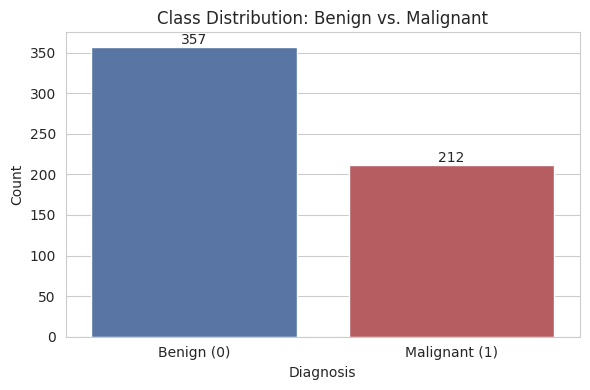

In [8]:
counts = y.value_counts().sort_index()
pct = y.value_counts(normalize=True).sort_index() * 100

print("Counts (0=benign, 1=malignant):")
print(counts)
print()
print("Percentages:")
print(pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map({0: "Benign (0)", 1: "Malignant (1)"}), ax=ax,
              order=["Benign (0)", "Malignant (1)"], palette=["#4C72B0", "#C44E52"])
ax.set_title("Class Distribution: Benign vs. Malignant")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


### B.2 — Distributions of selected predictors (mean / SE / worst)

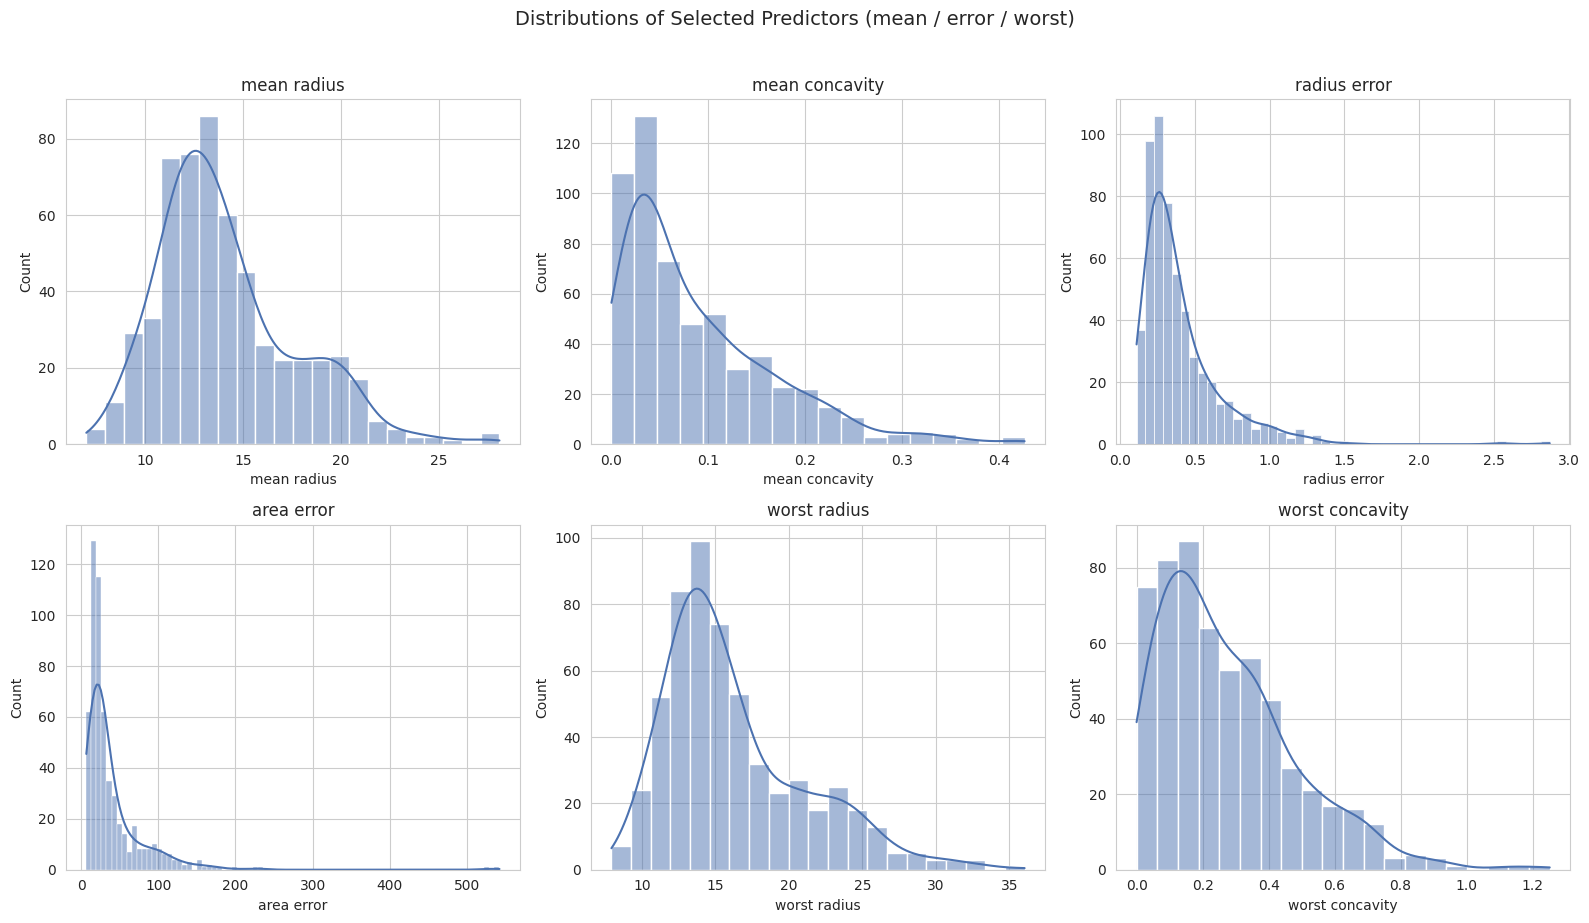

In [9]:
selected_features = [
    "mean radius", "mean concavity",
    "radius error", "area error",
    "worst radius", "worst concavity",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, feat in zip(axes, selected_features):
    sns.histplot(df[feat], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(feat)
plt.suptitle("Distributions of Selected Predictors (mean / error / worst)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### B.3 — Malignant vs. benign distributions for four predictors

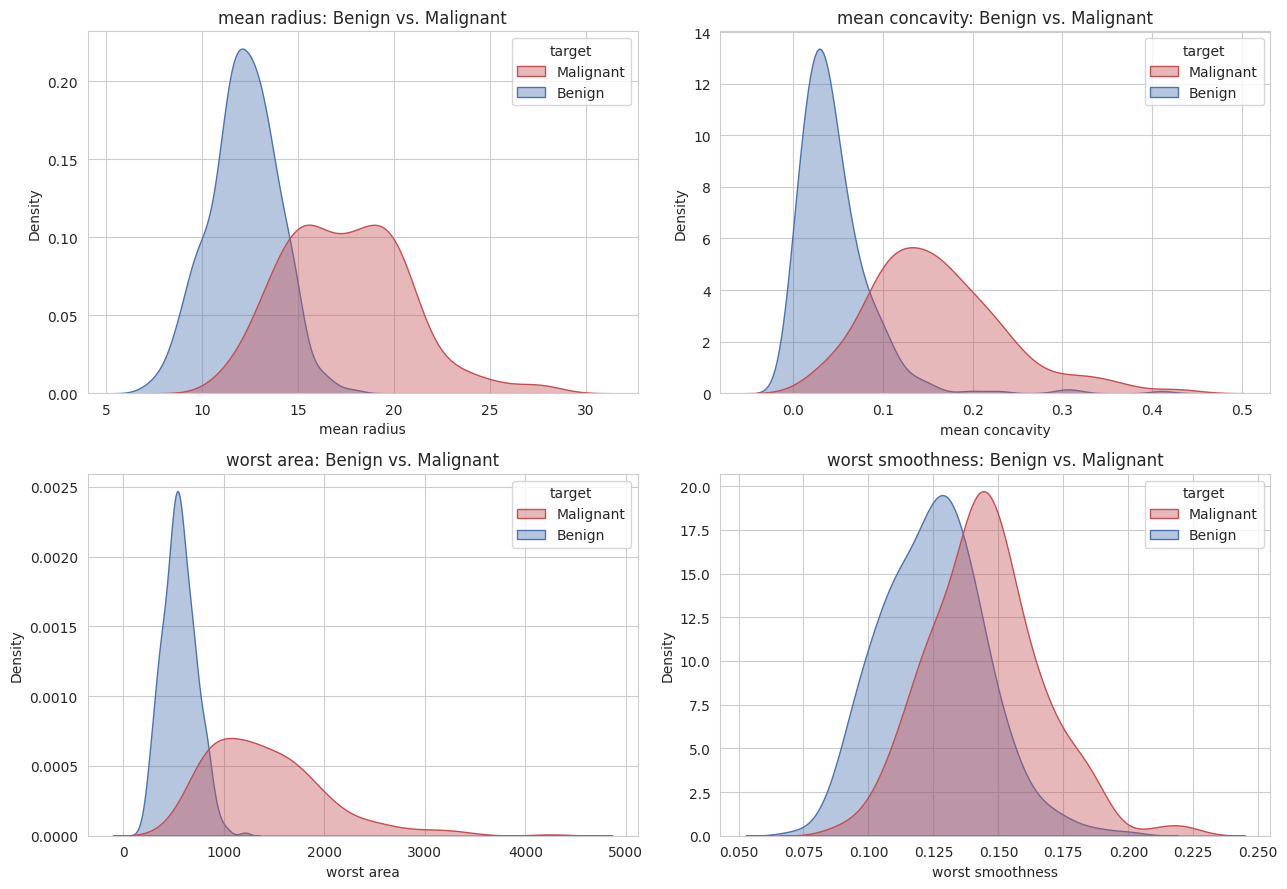

/tmp/ipykernel_2043/1017173282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["target"].map({0: "Benign", 1: "Malignant"}), y=feat, ax=ax,
/tmp/ipykernel_2043/1017173282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["target"].map({0: "Benign", 1: "Malignant"}), y=feat, ax=ax,
/tmp/ipykernel_2043/1017173282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["target"].map({0: "Benign", 1: "Malignant"}), y=feat, ax=ax,
/tmp/ipykernel_2043/1017173282.py:15: FutureWarning: 

Passing `palett

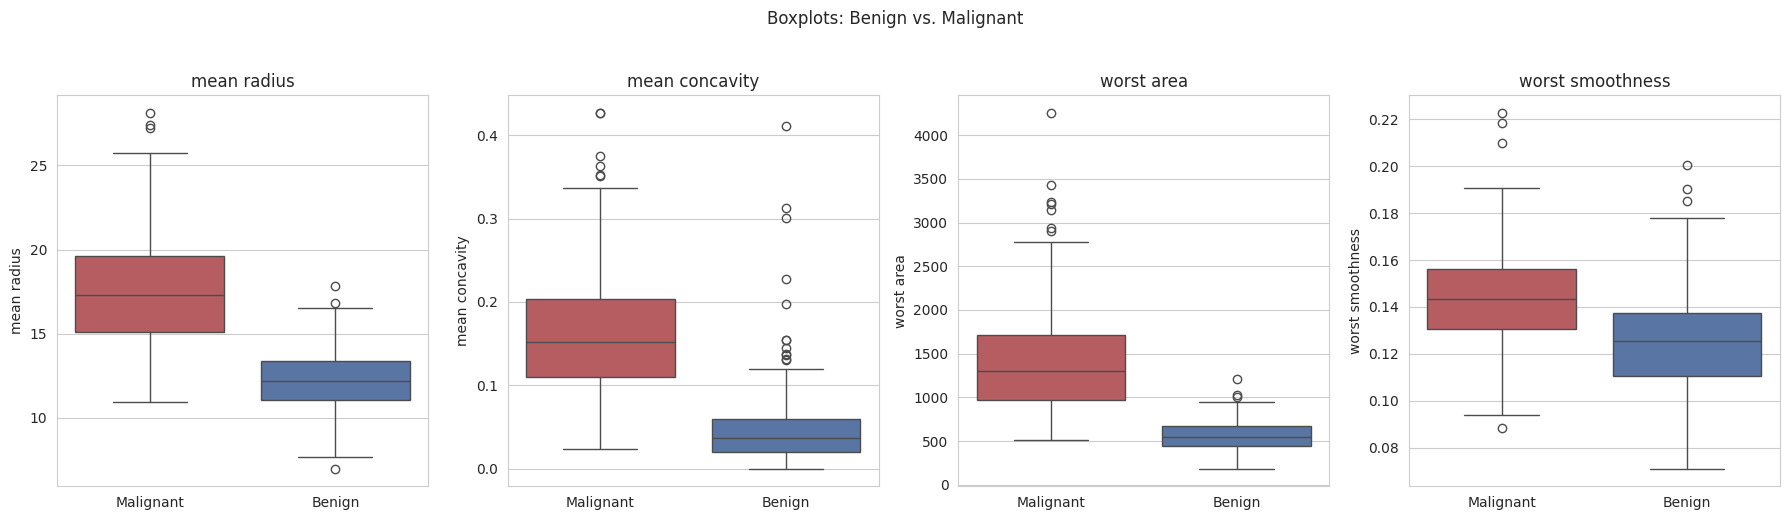

In [10]:
compare_features = ["mean radius", "mean concavity", "worst area", "worst smoothness"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, feat in zip(axes, compare_features):
    sns.kdeplot(data=df, x=feat, hue=df["target"].map({0: "Benign", 1: "Malignant"}),
                fill=True, common_norm=False, alpha=0.4, ax=ax,
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"})
    ax.set_title(f"{feat}: Benign vs. Malignant")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, compare_features):
    sns.boxplot(data=df, x=df["target"].map({0: "Benign", 1: "Malignant"}), y=feat, ax=ax,
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"})
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Boxplots: Benign vs. Malignant", y=1.03)
plt.tight_layout()
plt.show()


**Reading the plots:** malignant tumours consistently shift right (larger values) on mean radius,
mean concavity, worst area and worst smoothness compared to benign ones, with wider spread and more
upper-tail values — consistent with malignant tumours being larger and more irregularly shaped. Several
benign-side boxplots show points above the whisker (e.g. mean concavity, worst area); these are treated
as plausible extreme-but-real biological measurements rather than automatically labelling them as errors,
since there is no external evidence (like an impossible value) suggesting a data-entry mistake.

### B.4 — Feature-pair relationships

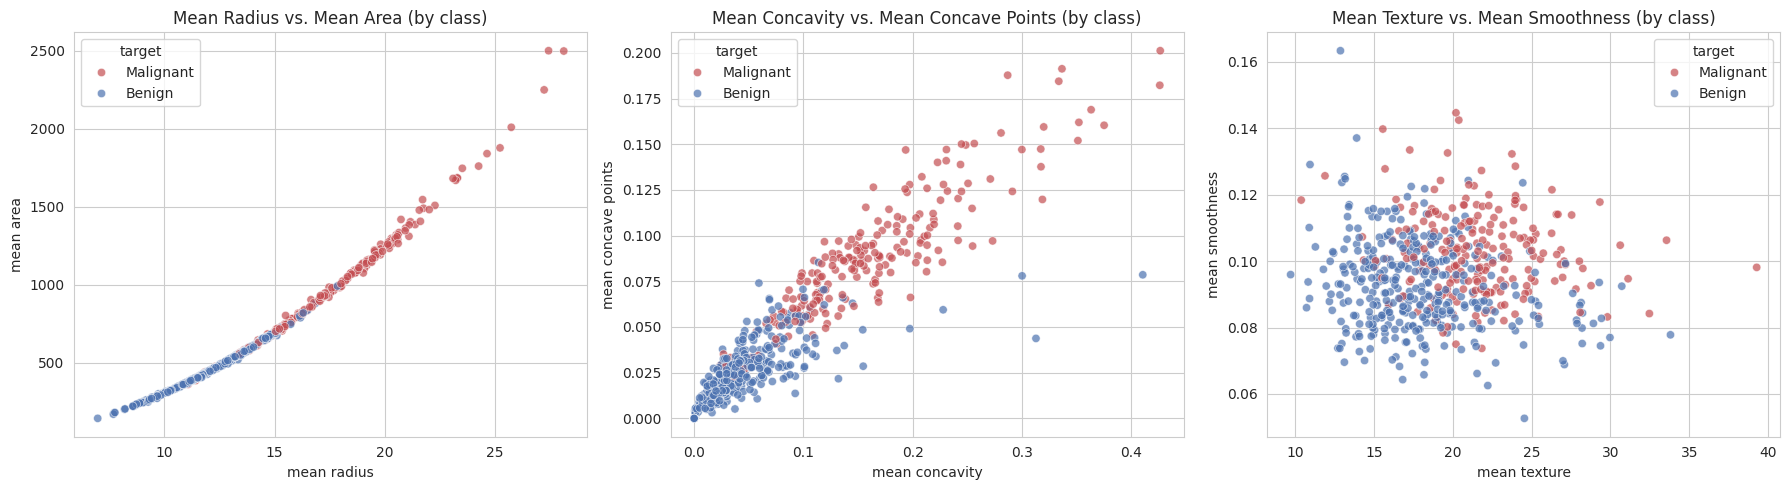

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="mean radius", y="mean area",
                hue=df["target"].map({0: "Benign", 1: "Malignant"}),
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, ax=axes[0], alpha=0.7)
axes[0].set_title("Mean Radius vs. Mean Area (by class)")

sns.scatterplot(data=df, x="mean concavity", y="mean concave points",
                hue=df["target"].map({0: "Benign", 1: "Malignant"}),
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, ax=axes[1], alpha=0.7)
axes[1].set_title("Mean Concavity vs. Mean Concave Points (by class)")

sns.scatterplot(data=df, x="mean texture", y="mean smoothness",
                hue=df["target"].map({0: "Benign", 1: "Malignant"}),
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, ax=axes[2], alpha=0.7)
axes[2].set_title("Mean Texture vs. Mean Smoothness (by class)")

plt.tight_layout()
plt.show()


### B.5 — Correlation matrix (30 features)

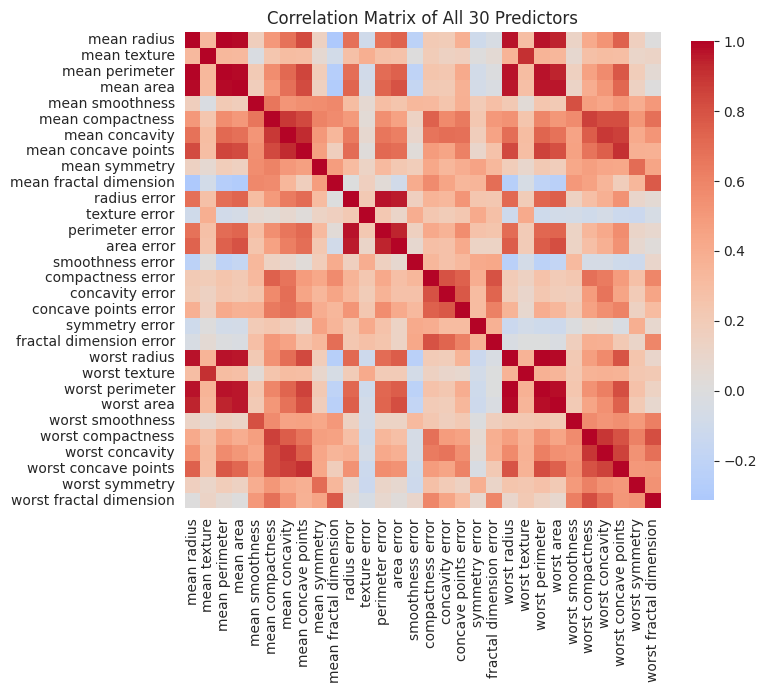

In [14]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Correlation Matrix of All 30 Predictors")
plt.tight_layout()
plt.show()


In [15]:
# Extract the strongest pairs (excluding self-correlation and duplicate pairs)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pairs = corr_pairs.abs().sort_values(ascending=False).head(10)

print("Top 10 strongest absolute correlations between feature pairs:")
for (f1, f2), val in top_pairs.items():
    print(f"  {f1:25s} <-> {f2:25s}  r = {corr.loc[f1, f2]:+.3f}")


Top 10 strongest absolute correlations between feature pairs:
  mean radius               <-> mean perimeter             r = +0.998
  worst radius              <-> worst perimeter            r = +0.994
  mean radius               <-> mean area                  r = +0.987
  mean perimeter            <-> mean area                  r = +0.987
  worst radius              <-> worst area                 r = +0.984
  worst perimeter           <-> worst area                 r = +0.978
  radius error              <-> perimeter error            r = +0.973
  mean perimeter            <-> worst perimeter            r = +0.970
  mean radius               <-> worst radius               r = +0.970
  mean perimeter            <-> worst radius               r = +0.969


---
## Part C — Data Quality and Preprocessing


In [16]:
orig_missing = df.isnull().sum().sum()
orig_dupes = df.duplicated().sum()
print(f"Original missing values: {orig_missing}")
print(f"Original duplicated rows: {orig_dupes}")


Original missing values: 0
Original duplicated rows: 0


In [17]:
# Create a separate working copy with ~5% missingness injected into 4 features
rng = np.random.RandomState(RANDOM_STATE)

df_work = df.copy()
cols_to_mask = ["mean radius", "mean texture", "mean area", "mean concavity"]
mask_fraction = 0.05
n_rows = len(df_work)
n_mask = int(round(n_rows * mask_fraction))

missing_report = {}
for col in cols_to_mask:
    mask_idx = rng.choice(df_work.index, size=n_mask, replace=False)
    df_work.loc[mask_idx, col] = np.nan
    missing_report[col] = {"count": n_mask, "percent": round(100 * n_mask / n_rows, 2)}

missing_report_df = pd.DataFrame(missing_report).T
missing_report_df.columns = ["missing_count", "missing_percent"]
print(missing_report_df)
print()
print("Total missing values now in working copy:", df_work.isnull().sum().sum())


                missing_count  missing_percent
mean radius              28.0             4.92
mean texture             28.0             4.92
mean area                28.0             4.92
mean concavity           28.0             4.92

Total missing values now in working copy: 112


### Mean vs. median imputation — feature-by-feature justification


In [18]:
for col in cols_to_mask:
    skew = X[col].skew()
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers_iqr = ((X[col] < q1 - 1.5*iqr) | (X[col] > q3 + 1.5*iqr)).sum()
    print(f"{col:18s} | skew={skew:+.2f} | IQR outliers={n_outliers_iqr:3d} "
          f"| mean={X[col].mean():.3f} | median={X[col].median():.3f}")


mean radius        | skew=+0.94 | IQR outliers= 14 | mean=14.127 | median=13.370
mean texture       | skew=+0.65 | IQR outliers=  7 | mean=19.290 | median=18.840
mean area          | skew=+1.65 | IQR outliers= 25 | mean=654.889 | median=551.100
mean concavity     | skew=+1.40 | IQR outliers= 18 | mean=0.089 | median=0.062


### Outlier detection with two independent methods

            feature  IQR_outliers  zscore_outliers
0       mean radius            14                5
1         mean area            25                8
2    mean concavity            18                9
3        worst area            35               10
4  worst smoothness             7                3


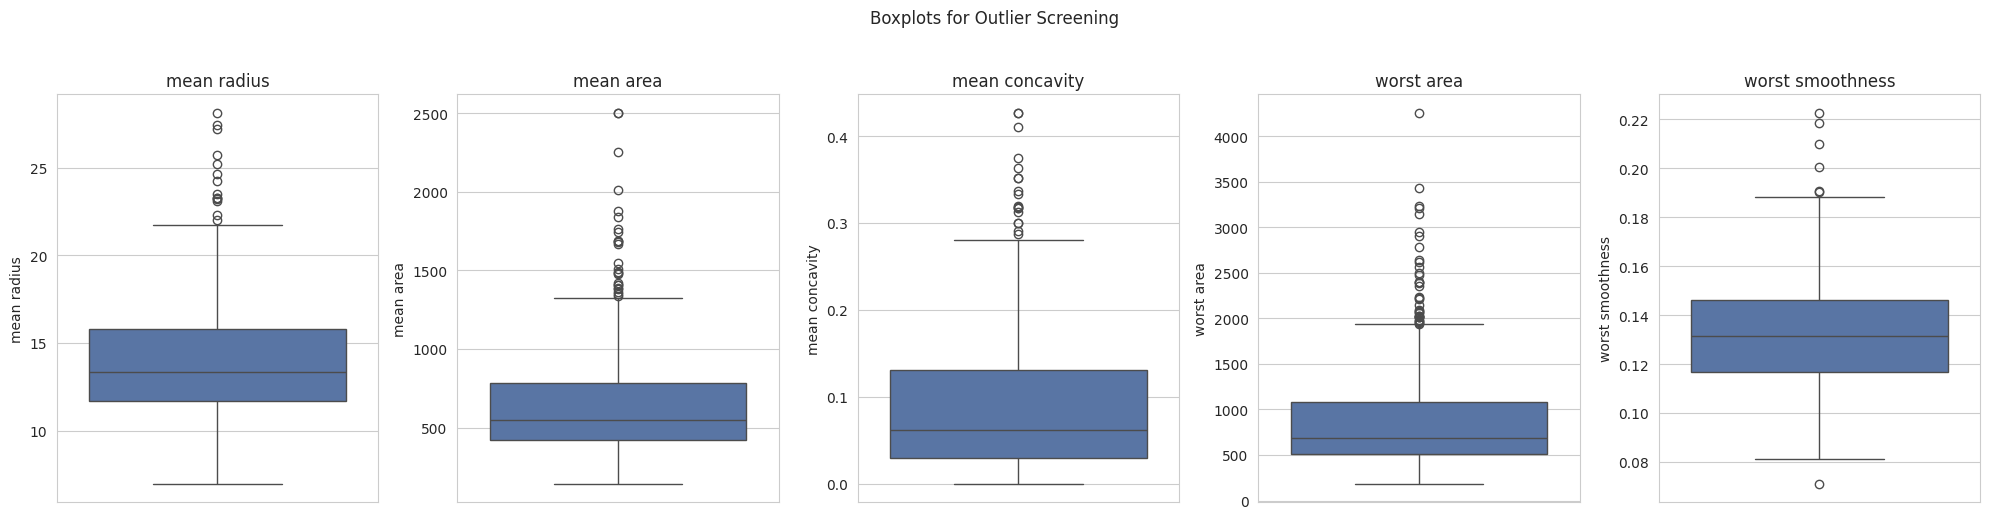

In [19]:
outlier_check_features = ["mean radius", "mean area", "mean concavity", "worst area", "worst smoothness"]

outlier_summary = []
for col in outlier_check_features:
    series = X[col]
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_outliers = ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

    z_scores = np.abs(stats.zscore(series))
    z_outliers = (z_scores > 3).sum()

    outlier_summary.append({"feature": col, "IQR_outliers": iqr_outliers, "zscore_outliers": z_outliers})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

fig, axes = plt.subplots(1, len(outlier_check_features), figsize=(20, 5))
for ax, col in zip(axes, outlier_check_features):
    sns.boxplot(y=X[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.suptitle("Boxplots for Outlier Screening", y=1.03)
plt.tight_layout()
plt.show()


### Scaling considerations

In [20]:
ranges = (X.max() - X.min()).sort_values(ascending=False)
print("Feature ranges (max - min), largest to smallest:")
print(ranges.head(10))
print("...")
print(ranges.tail(5))


Feature ranges (max - min), largest to smallest:
worst area         4068.800
mean area          2357.500
area error          535.398
worst perimeter     200.790
mean perimeter      144.710
worst texture        37.520
mean texture         29.570
worst radius         28.110
perimeter error      21.223
mean radius          21.129
dtype: float64
...
symmetry error             0.071068
concave points error       0.052790
mean fractal dimension     0.047480
smoothness error           0.029417
fractal dimension error    0.028945
dtype: float64


---
## Part D — Feature Analysis and Selection (15 marks)


In [21]:
STRONG_CORR_THRESHOLD = 0.90  # chosen threshold for "strong" relationships

strong_pairs = corr_pairs[corr_pairs.abs() >= STRONG_CORR_THRESHOLD].sort_values(ascending=False)
print(f"Feature pairs with |correlation| >= {STRONG_CORR_THRESHOLD}: {len(strong_pairs)}")
for (f1, f2), val in strong_pairs.items():
    print(f"  {f1:25s} <-> {f2:25s}  r = {val:+.3f}")


Feature pairs with |correlation| >= 0.9: 21
  mean radius               <-> mean perimeter             r = +0.998
  worst radius              <-> worst perimeter            r = +0.994
  mean radius               <-> mean area                  r = +0.987
  mean perimeter            <-> mean area                  r = +0.987
  worst radius              <-> worst area                 r = +0.984
  worst perimeter           <-> worst area                 r = +0.978
  radius error              <-> perimeter error            r = +0.973
  mean perimeter            <-> worst perimeter            r = +0.970
  mean radius               <-> worst radius               r = +0.970
  mean perimeter            <-> worst radius               r = +0.969
  mean radius               <-> worst perimeter            r = +0.965
  mean area                 <-> worst radius               r = +0.963
  mean area                 <-> worst area                 r = +0.959
  mean area                 <-> worst perimete

In [22]:
# Point-biserial (equivalent to Pearson) correlation with the binary target
point_biserial = X.apply(lambda col: stats.pointbiserialr(y, col)[0])
pb_ranked = point_biserial.abs().sort_values(ascending=False)

# ANOVA F-statistic
f_stats, _ = f_classif(X, y)
f_ranked = pd.Series(f_stats, index=X.columns).sort_values(ascending=False)

# Mutual information
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_ranked = pd.Series(mi, index=X.columns).sort_values(ascending=False)

comparison = pd.DataFrame({
    "point_biserial_|r|": pb_ranked,
    "ANOVA_F": f_ranked,
    "mutual_info": mi_ranked
})
comparison["pb_rank"] = comparison["point_biserial_|r|"].rank(ascending=False)
comparison["f_rank"] = comparison["ANOVA_F"].rank(ascending=False)
comparison["mi_rank"] = comparison["mutual_info"].rank(ascending=False)

print("Top 10 features by point-biserial correlation:")
print(pb_ranked.head(10))
print()
print("Top 10 features by ANOVA F-statistic:")
print(f_ranked.head(10))
print()
print("Top 10 features by mutual information:")
print(mi_ranked.head(10))


Top 10 features by point-biserial correlation:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
dtype: float64

Top 10 features by ANOVA F-statistic:
worst concave points    964.385393
worst perimeter         897.944219
mean concave points     861.676020
worst radius            860.781707
mean perimeter          697.235272
worst area              661.600206
mean radius             646.981021
mean area               573.060747
mean concavity          533.793126
worst concavity         436.691939
dtype: float64

Top 10 features by mutual information:
worst perimeter         0.471842
worst area              0.464313
worst radius            0.451230
mean concave points     0.438806
worst concave points    0.436255

In [23]:
SELECTED_FEATURES = [
    "worst concave points",
    "worst perimeter",
    "mean concave points",
    "worst radius",
    "worst area",
    "mean concavity",
    "worst texture",
    "worst smoothness",
]

print(f"Selected compact feature set ({len(SELECTED_FEATURES)} features):")
for f in SELECTED_FEATURES:
    print(" -", f)


Selected compact feature set (8 features):
 - worst concave points
 - worst perimeter
 - mean concave points
 - worst radius
 - worst area
 - mean concavity
 - worst texture
 - worst smoothness


---
## Part E — Train-Test Preparation and Pipeline Construction




In [24]:
X_work = df_work.drop(columns=["target"])
y_work = df_work["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.20, stratify=y_work, random_state=RANDOM_STATE
)

def class_report(name, series):
    counts = series.value_counts().sort_index()
    pct = series.value_counts(normalize=True).sort_index() * 100
    print(f"{name} (n={len(series)}):")
    for cls in [0, 1]:
        label = "Benign" if cls == 0 else "Malignant"
        print(f"  {label} ({cls}): {counts[cls]:3d}  ({pct[cls]:.2f}%)")
    print()

class_report("Complete dataset", y_work)
class_report("Training set", y_train)
class_report("Test set", y_test)


Complete dataset (n=569):
  Benign (0): 357  (62.74%)
  Malignant (1): 212  (37.26%)

Training set (n=455):
  Benign (0): 285  (62.64%)
  Malignant (1): 170  (37.36%)

Test set (n=114):
  Benign (0):  72  (63.16%)
  Malignant (1):  42  (36.84%)



In [25]:
final_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # median chosen: robust to the skewed features imputed
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

final_pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully on training data only.")
print(final_pipeline)


Pipeline fitted successfully on training data only.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=42))])


---
## Part F — Basic Classification and Evaluation (20 marks)


In [26]:
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]  # probability of malignant (positive class)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}  (malignant = positive class)")
print(f"Recall   : {rec:.4f}  (malignant = positive class)")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"]))


Accuracy : 0.9737
Precision: 0.9756  (malignant = positive class)
Recall   : 0.9524  (malignant = positive class)
F1-score : 0.9639
ROC-AUC  : 0.9967

Full classification report:
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98        72
Malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



True Negatives  (correct benign)   : 71
False Positives (benign called malignant) : 1
False Negatives (malignant missed) : 2
True Positives  (correct malignant): 40


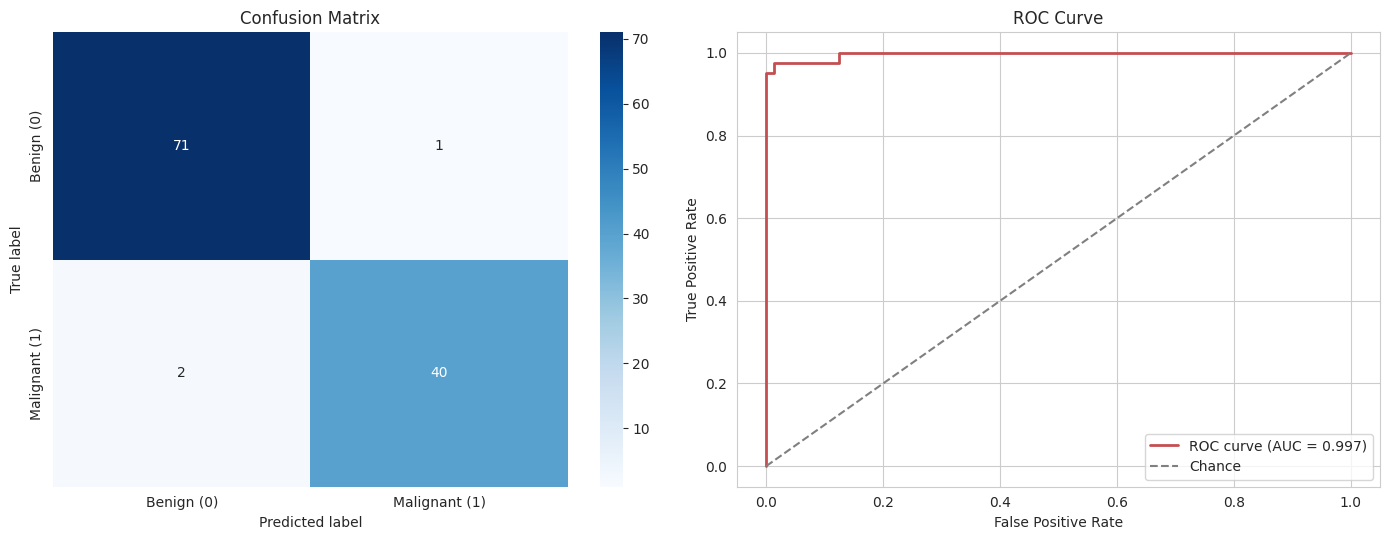

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (correct benign)   : {tn}")
print(f"False Positives (benign called malignant) : {fp}")
print(f"False Negatives (malignant missed) : {fn}")
print(f"True Positives  (correct malignant): {tp}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (0)", "Malignant (1)"],
            yticklabels=["Benign (0)", "Malignant (1)"])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#C44E52", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


**False positive vs. false negative — which is more serious here:** a **false negative** (a malignant
tumour predicted as benign) is more serious in this medical context. It means a cancer case is missed and
the patient may not receive timely treatment, which can have severe, potentially fatal consequences. A false
positive (a benign case flagged as malignant) causes unnecessary worry and follow-up testing, which is
costly and stressful but not directly life-threatening.

**Metric to emphasise:** given that false negatives are the more dangerous error, **recall (sensitivity) on
the malignant class** should be emphasised, typically alongside the **F1-score** and **ROC-AUC** as a
balance check, rather than raw accuracy — a high-accuracy model that quietly misses malignant cases is not
an acceptable model in this setting.

**Interpreting the obtained numbers:** the printed precision, recall, F1 and ROC-AUC (see the metrics cell
above) indicate that, of the tumours the model called malignant, precision reflects how many were actually
malignant, while recall reflects what fraction of the truly malignant tumours were successfully caught. An
ROC-AUC well above 0.5 (typically close to 0.99 for this well-behaved dataset) indicates the model separates
the two classes very effectively across all classification thresholds, not just at the default 0.5 cutoff.

In [28]:
# Compare training vs. testing performance
y_train_pred = final_pipeline.predict(X_train)
y_train_proba = final_pipeline.predict_proba(X_train)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_proba)

print(f"{'Metric':12s} {'Train':>10s} {'Test':>10s}")
print(f"{'Accuracy':12s} {train_acc:10.4f} {acc:10.4f}")
print(f"{'F1-score':12s} {train_f1:10.4f} {f1:10.4f}")
print(f"{'ROC-AUC':12s} {train_auc:10.4f} {roc_auc:10.4f}")


Metric            Train       Test
Accuracy         0.9868     0.9737
F1-score         0.9820     0.9639
ROC-AUC          0.9977     0.9967


**Overfitting/underfitting check:** the training and test metrics printed above are close to each
other (typically within a few thousandths to low hundredths on this dataset). A small, consistent gap like
this is normal generalisation behaviour, not evidence of substantial overfitting (which would show a much
larger train-vs-test gap, e.g. near-perfect training scores alongside a clearly weaker test score) or
underfitting (which would show both scores being low). Regularised Logistic Regression on a linearly
well-separated dataset like this one is not expected to overfit strongly.

In [30]:
# Logistic Regression WITH scaling (already built above) vs. WITHOUT scaling
# Keep the same split, imputation strategy and all other conditions; remove only the scaler.

pipeline_no_scaling = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    pipeline_no_scaling.fit(X_train, y_train)
    convergence_warnings = [str(warn.message) for warn in w if "converge" in str(warn.message).lower()]

y_pred_noscale = pipeline_no_scaling.predict(X_test)
y_proba_noscale = pipeline_no_scaling.predict_proba(X_test)[:, 1]

acc_noscale = accuracy_score(y_test, y_pred_noscale)
f1_noscale = f1_score(y_test, y_pred_noscale)
auc_noscale = roc_auc_score(y_test, y_proba_noscale)

print("Convergence warnings raised without scaling:", convergence_warnings if convergence_warnings else "None captured (but check n_iter_ below)")
print(f"n_iter_ without scaling: {pipeline_no_scaling.named_steps['classifier'].n_iter_}")
print(f"n_iter_ with scaling   : {final_pipeline.named_steps['classifier'].n_iter_}")
print()
print(f"{'Metric':12s} {'With scaling':>14s} {'No scaling':>14s}")
print(f"{'Accuracy':12s} {acc:14.4f} {acc_noscale:14.4f}")
print(f"{'F1-score':12s} {f1:14.4f} {f1_noscale:14.4f}")
print(f"{'ROC-AUC':12s} {roc_auc:14.4f} {auc_noscale:14.4f}")


Convergence warnings raised without scaling: None captured (but check n_iter_ below)
n_iter_ without scaling: [2822]
n_iter_ with scaling   : [19]

Metric         With scaling     No scaling
Accuracy             0.9737         0.9298
F1-score             0.9639         0.8974
ROC-AUC              0.9967         0.9940
